## Clustering y segmentación de vehículos

En esta etapa se aplica un modelo de clustering para segmentar los vehículos usados de AutoTec en grupos con características similares.

El objetivo es identificar perfiles de vehículos considerando variables directamente relacionadas con la depreciación y el valor de mercado: precio, kilometraje y antigüedad del vehículo.

A diferencia de los análisis anteriores, este apartado no busca analizar cada variable por separado, sino agrupar vehículos según patrones comunes para apoyar futuras etapas de segmentación, valorización y modelamiento predictivo.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

from dotenv import load_dotenv
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, trim, current_date, year as spark_year

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

def formato_pesos_eje():
    plt.gca().yaxis.set_major_formatter(
        ticker.FuncFormatter(lambda x, pos: f"${x:,.0f}".replace(",", "."))
    )

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

if MONGO_URI is None:
    raise ValueError("No se encontró la variable MONGO_URI en el archivo .env")

spark = (
    SparkSession.builder
    .appName("AutoTec_Clustering")
    .config("spark.mongodb.read.connection.uri", MONGO_URI)
    .config("spark.mongodb.write.connection.uri", MONGO_URI)
    .config("spark.jars.packages", "org.mongodb.spark:mongo-spark-connector_2.12:10.1.1")
    .getOrCreate()
)

df = (
    spark.read.format("mongodb")
    .option("database", "proyecto_bigdata")
    .option("collection", "Contenedor_Autos_Limpio")
    .load()
)

print("Cantidad de registros cargados:", df.count())
df.printSchema()

Cantidad de registros cargados: 1988
root
 |-- _id: string (nullable = true)
 |-- cat_combustible: integer (nullable = true)
 |-- ciudad: string (nullable = true)
 |-- combustible: string (nullable = true)
 |-- fecha_captura: string (nullable = true)
 |-- foto_url: string (nullable = true)
 |-- grupo: string (nullable = true)
 |-- kilometraje: double (nullable = true)
 |-- marca: string (nullable = true)
 |-- modelo: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- url: string (nullable = true)
 |-- usuario: string (nullable = true)
 |-- year: integer (nullable = true)



In [2]:
df_cluster = (
    df.select(
        "precio",
        "kilometraje",
        "year",
        "marca",
        "modelo",
        "combustible"
    )
    .dropna(subset=["precio", "kilometraje", "year"])
)

df_cluster = df_cluster.withColumn(
    "antiguedad_auto",
    spark_year(current_date()) - col("year")
)

df_cluster = df_cluster.filter(col("precio") > 0)
df_cluster = df_cluster.filter(col("kilometraje") >= 0)
df_cluster = df_cluster.filter(col("antiguedad_auto") >= 0)

df_pd = df_cluster.select(
    "precio",
    "kilometraje",
    "antiguedad_auto"
).toPandas()

df_pd.head()

,precio,kilometraje,antiguedad_auto
0,21990000.0,27294.0,2
1,21990000.0,11766.0,2
2,18990000.0,84917.0,8
3,15890000.0,93687.0,8
4,29490000.0,45021.0,2


## Variables utilizadas para la segmentación

Para el clustering se utilizaron tres variables principales: precio, kilometraje y antigüedad del vehículo.

Estas variables fueron seleccionadas porque se relacionan directamente con el proceso de depreciación. El precio representa el valor de mercado actual, el kilometraje refleja el nivel de uso acumulado y la antigüedad muestra cuántos años han pasado desde la fabricación del vehículo.

Antes de aplicar K-Means, las variables se escalan para evitar que una variable con valores más grandes, como el precio o el kilometraje, domine el resultado del modelo.

In [3]:
variables = ["precio", "kilometraje", "antiguedad_auto"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pd[variables])

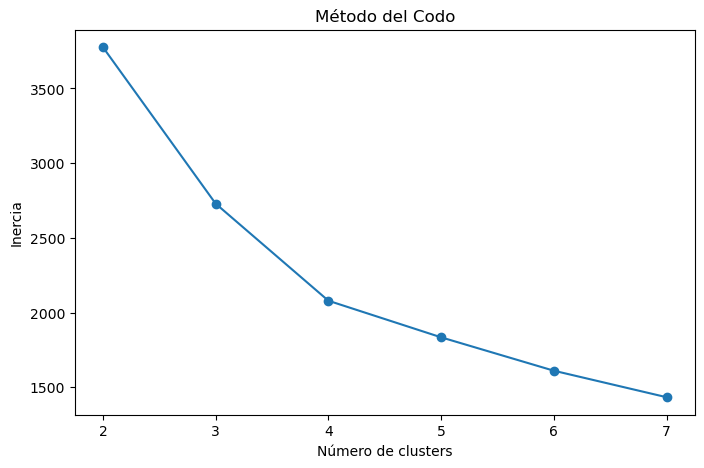

In [4]:
inercia = []

for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 8), inercia, marker="o")

plt.title("Método del Codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.show()

### Interpretación del Método del Codo

La curva presenta una disminución importante de la inercia entre K=2 y K=4. A partir de ese punto la reducción comienza a ser menor, indicando que agregar más clusters aporta una mejora cada vez menos significativa. Esto sugiere que una solución cercana a 3 grupos puede representar adecuadamente la estructura de los datos.

In [5]:
for k in range(2, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K={k} | Silhouette: {score:.3f}")

K=2 | Silhouette: 0.374
K=3 | Silhouette: 0.398
K=4 | Silhouette: 0.367
K=5 | Silhouette: 0.325
K=6 | Silhouette: 0.315
K=7 | Silhouette: 0.288


## Selección del modelo de clustering

Se aplicó el algoritmo K-Means porque permite agrupar vehículos con características similares a partir de variables numéricas.

La cantidad de clusters se evaluó utilizando el Método del Codo y el índice Silhouette. El Método del Codo permite observar desde qué punto la reducción de la inercia comienza a ser menor, mientras que el índice Silhouette ayuda a medir qué tan separados y consistentes son los grupos formados.

De acuerdo con los resultados obtenidos, se seleccionan 3 clusters, ya que permiten segmentar la base en grupos interpretables y coherentes con distintos perfiles de vehículos usados.

In [6]:
k_optimo = 3

kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
df_pd["cluster"] = kmeans_final.fit_predict(X_scaled)

df_pd.head()

,precio,kilometraje,antiguedad_auto,cluster
0,21990000.0,27294.0,2,1
1,21990000.0,11766.0,2,1
2,18990000.0,84917.0,8,0
3,15890000.0,93687.0,8,0
4,29490000.0,45021.0,2,2


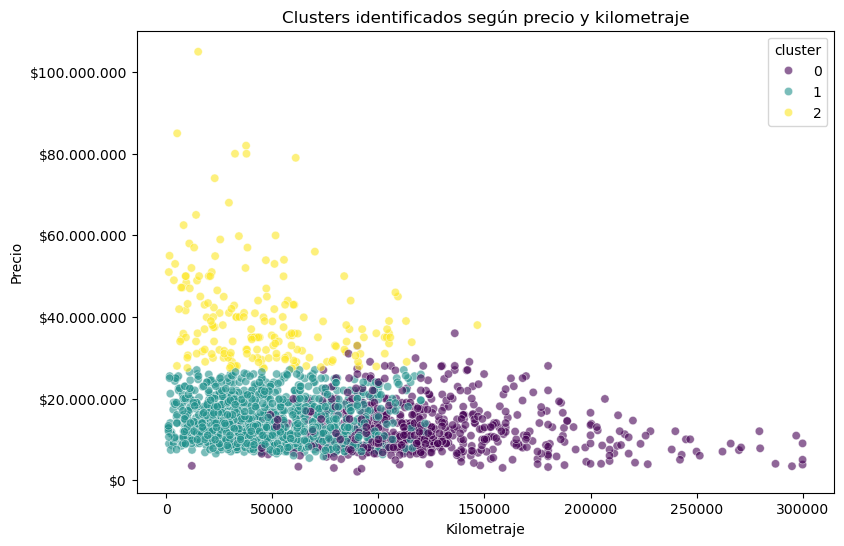

In [7]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_pd,
    x="kilometraje",
    y="precio",
    hue="cluster",
    palette="viridis",
    alpha=0.6
)

plt.title("Clusters identificados según precio y kilometraje")
plt.xlabel("Kilometraje")
plt.ylabel("Precio")
formato_pesos_eje()

plt.show()

In [8]:
perfil_clusters = (
    df_pd.groupby("cluster")[variables]
    .mean()
    .round(0)
    .reset_index()
)

perfil_clusters["precio"] = perfil_clusters["precio"].apply(lambda x: f"${x:,.0f}".replace(",", "."))
perfil_clusters["kilometraje"] = perfil_clusters["kilometraje"].apply(lambda x: f"{x:,.0f}".replace(",", "."))
perfil_clusters["antiguedad_auto"] = perfil_clusters["antiguedad_auto"].apply(lambda x: f"{x:,.0f} años".replace(",", "."))

perfil_clusters = perfil_clusters.rename(columns={
    "cluster": "Cluster",
    "precio": "Precio promedio",
    "kilometraje": "Kilometraje promedio",
    "antiguedad_auto": "Antigüedad promedio"
})

perfil_clusters

,Cluster,Precio promedio,Kilometraje promedio,Antigüedad promedio
0,0,$12.679.934,125.322,8 años
1,1,$14.581.081,47.224,3 años
2,2,$39.856.736,45.605,3 años


In [9]:
cantidad_clusters = (
    df_pd["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cantidad_clusters.columns = ["Cluster", "Cantidad de vehículos"]

cantidad_clusters

,Cluster,Cantidad de vehículos
0,0,611
1,1,1184
2,2,193


## Interpretación del clustering

El modelo K-Means permitió separar los vehículos en tres grupos según precio, kilometraje y antigüedad. Esta segmentación ayuda a comprender que el mercado de vehículos usados no se comporta de manera uniforme, sino que existen perfiles diferenciados según nivel de uso, años de antigüedad y valor comercial.

El Cluster 0 agrupa vehículos relativamente recientes, con una antigüedad promedio cercana a 3 años, kilometraje moderado y precios intermedios. Este grupo representa automóviles que aún conservan una parte importante de su valor de mercado.

El Cluster 1 concentra vehículos con mayor antigüedad y kilometraje promedio. Estos vehículos presentan los precios más bajos entre los grupos identificados, reflejando un mayor nivel de depreciación asociado al uso acumulado y al paso del tiempo.

El Cluster 2 reúne vehículos con los precios promedio más altos, menor kilometraje y baja antigüedad. Este segmento puede asociarse a vehículos de gama alta o modelos recientes que mantienen una valorización superior dentro del mercado.

Además, el Cluster 0 concentra la mayor cantidad de registros (1184 vehículos), seguido por el Cluster 1 (611 vehículos) y el Cluster 2 (193 vehículos). Esto indica que la mayor parte de los vehículos analizados corresponde a unidades de precio intermedio, mientras que los vehículos de alto valor representan una proporción menor dentro de la base de datos.

En conjunto, los resultados muestran que la depreciación de un vehículo depende de la combinación entre antigüedad, kilometraje y valor comercial. La segmentación obtenida permite identificar perfiles diferenciados que pueden ser utilizados en futuras etapas de análisis predictivo y valorización de vehículos.

## Conclusión

El análisis de clustering permitió identificar tres segmentos principales dentro de la base de vehículos usados de AutoTec. Los grupos obtenidos muestran diferencias claras entre vehículos de mayor depreciación, vehículos de comportamiento intermedio y vehículos de mayor valor comercial.

Los resultados refuerzan la importancia del kilometraje y la antigüedad como variables clave para explicar la depreciación, pero también muestran que existen vehículos que conservan precios altos pese al uso o al paso del tiempo.

Esta segmentación entrega una base útil para futuras etapas del proyecto, especialmente para modelos predictivos de precio, clasificación de vehículos y toma de decisiones orientadas al mercado automotriz usado.